In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.decomposition import PCA


In [2]:
df = pd.read_csv("cleaned_utah.csv")

df = df.drop(columns=['Unnamed: 0','listPrice'])

df = df.dropna(subset=["property_type"])

top2 = df["property_type"].value_counts().nlargest(2).index
df = df[df["property_type"].isin(top2)]

for col in df.columns:
    if col != "property_type":
        df[col] = df[col].astype(int)


<ipython-input-2-1cee43f96c40>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(int)
<ipython-input-2-1cee43f96c40>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[col] = df[col].astype(int)
<ipython-input-2-1cee43f96c40>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

In [3]:
df.head()

,year_built,beds,baths,baths_full,garage,sqft,stories,property_type
0,2003,4,0,2,2,2400,2,Affordable
1,2003,3,3,2,2,1606,2,Average
2,2003,3,3,2,2,1606,2,Average
3,2020,3,3,2,2,1736,2,Average
4,2003,4,0,2,2,2400,2,Affordable


In [4]:

label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["property_type"])

X = df.drop(columns=["property_type", "label"]).select_dtypes(include=[np.number]).dropna()
y = df.loc[X.index, "label"]


<ipython-input-4-d1bae054c39b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = label_encoder.fit_transform(df["property_type"])


In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [6]:
X_train.head()

,year_built,beds,baths,baths_full,garage,sqft,stories
800,2018,3,2,2,2,1347,2
299,2019,3,2,2,2,2804,2
336,2003,3,3,2,2,3054,2
338,2003,4,3,2,2,2400,2
2,2003,3,3,2,2,1606,2


In [7]:
X_train.to_csv("X_Train_Data.csv")

In [8]:
X_test.head()

,year_built,beds,baths,baths_full,garage,sqft,stories
357,2003,4,0,2,2,2400,2
1135,2003,5,3,2,2,2688,2
435,2003,4,0,2,2,2400,2
558,2003,4,0,2,2,2400,2
1003,2003,4,0,2,2,2400,2


In [9]:
X_test.to_csv("X_test.csv")

In [10]:
y_train.head()

,label
800,1
299,1
336,1
338,1
2,1


In [11]:
y_train.to_csv("y_train.csv")

In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [13]:

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


print(X_train_scaled_df.head())



     year_built      beds     baths  baths_full  garage      sqft  stories
800    3.459494 -1.327307  0.725602         0.0     0.0 -2.389097      0.0
299    3.697734 -1.327307  0.725602         0.0     0.0  1.549651      0.0
336   -0.114118 -1.327307  1.468922         0.0     0.0  2.225483      0.0
338   -0.114118  0.574087  1.468922         0.0     0.0  0.457507      0.0
2     -0.114118 -1.327307  1.468922         0.0     0.0 -1.688936      0.0


In [14]:
X_train_scaled_df.to_csv("X_train_scaled_df.csv")

In [15]:
print(X_test_scaled_df.head())

      year_built      beds     baths  baths_full  garage      sqft  stories
357    -0.114118  0.574087 -0.761038         0.0     0.0  0.457507      0.0
1135   -0.114118  2.475481  1.468922         0.0     0.0  1.236065      0.0
435    -0.114118  0.574087 -0.761038         0.0     0.0  0.457507      0.0
558    -0.114118  0.574087 -0.761038         0.0     0.0  0.457507      0.0
1003   -0.114118  0.574087 -0.761038         0.0     0.0  0.457507      0.0


In [16]:
X_test_scaled_df.to_csv("X_test_scaled_df.csv")

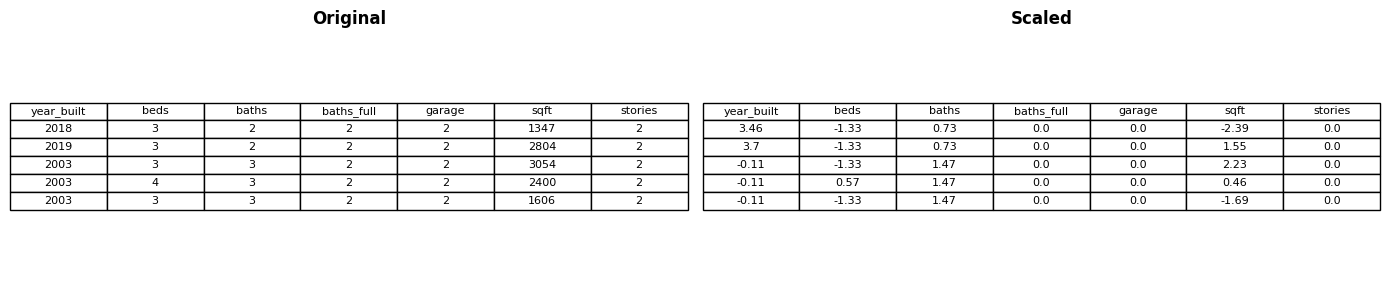

In [17]:
def show_side_by_side(original, scaled, title1="Original", title2="Scaled"):
    original_df = original.head()
    scaled_df = pd.DataFrame(scaled[:5], columns=original.columns)
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    for ax, df, title in zip(axes, [original_df, scaled_df], [title1, title2]):
        ax.axis('off')
        ax.table(cellText=np.round(df.values, 2), colLabels=df.columns,
                 loc='center', cellLoc='center')
        ax.set_title(title, fontweight="bold")
    plt.tight_layout()
    plt.show()

show_side_by_side(X_train, X_train_scaled)


In [18]:
kernels = ['linear', 'rbf', 'poly']
costs = [0.1, 1, 10]
results = []

for kernel in kernels:
    for C in costs:
        model = SVC(kernel=kernel, C=C, random_state=42)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)

        results.append({
            "kernel": kernel,
            "C": C,
            "model": model,
            "accuracy": acc,
            "confusion_matrix": cm,
            "classification_report": report
        })

        # Print classification report
        print(f"\nKernel: {kernel}, C: {C}, Accuracy: {acc:.4f}")
        print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



Kernel: linear, C: 0.1, Accuracy: 0.8507
              precision    recall  f1-score   support

  Affordable       0.90      0.89      0.89       156
     Average       0.74      0.75      0.75        65

    accuracy                           0.85       221
   macro avg       0.82      0.82      0.82       221
weighted avg       0.85      0.85      0.85       221


Kernel: linear, C: 1, Accuracy: 0.8462
              precision    recall  f1-score   support

  Affordable       0.89      0.89      0.89       156
     Average       0.74      0.74      0.74        65

    accuracy                           0.85       221
   macro avg       0.81      0.81      0.81       221
weighted avg       0.85      0.85      0.85       221


Kernel: linear, C: 10, Accuracy: 0.8462
              precision    recall  f1-score   support

  Affordable       0.89      0.89      0.89       156
     Average       0.74      0.74      0.74        65

    accuracy                           0.85       221
   ma

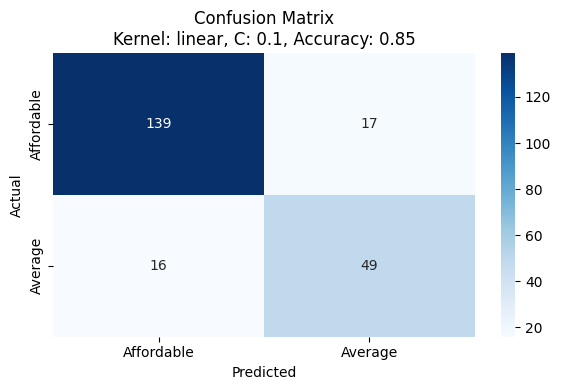

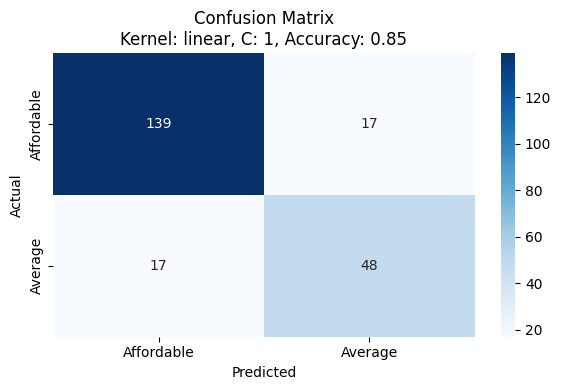

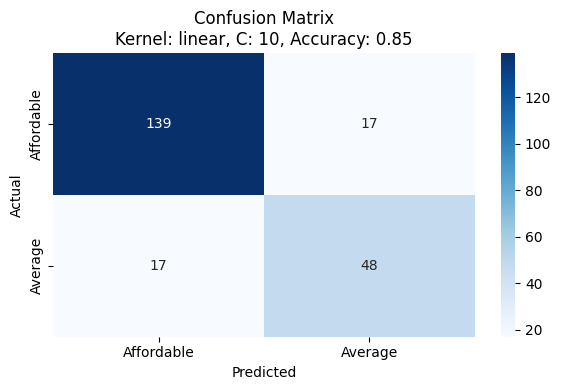

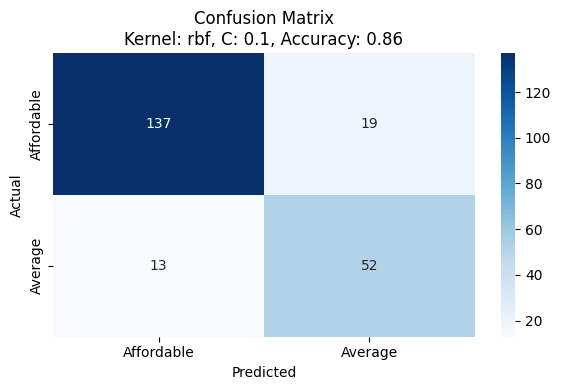

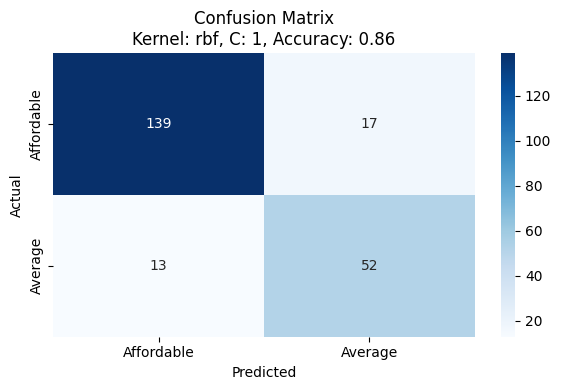

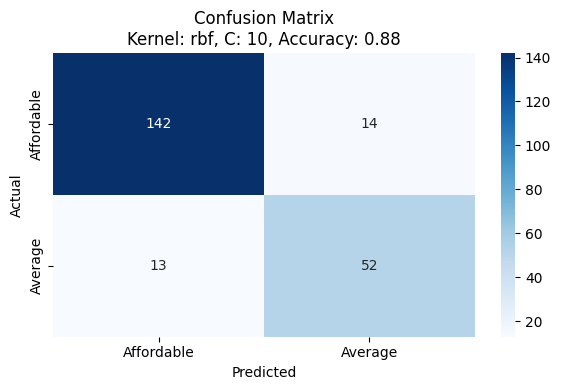

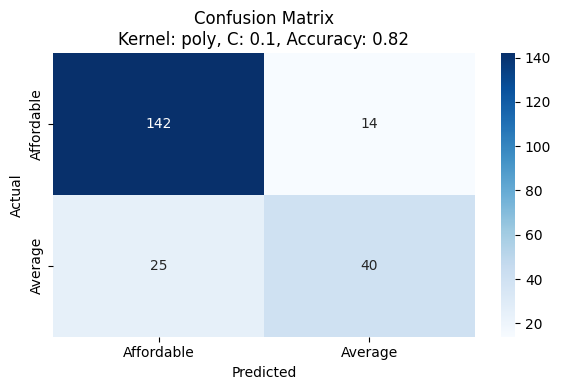

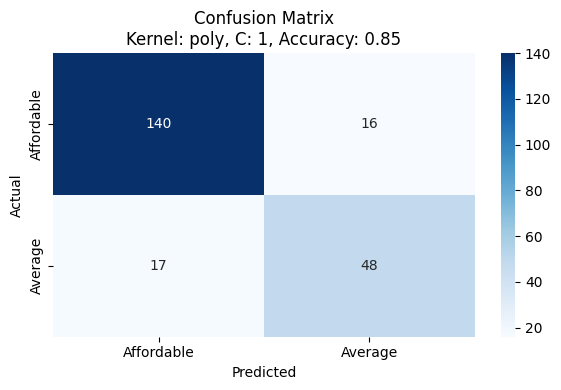

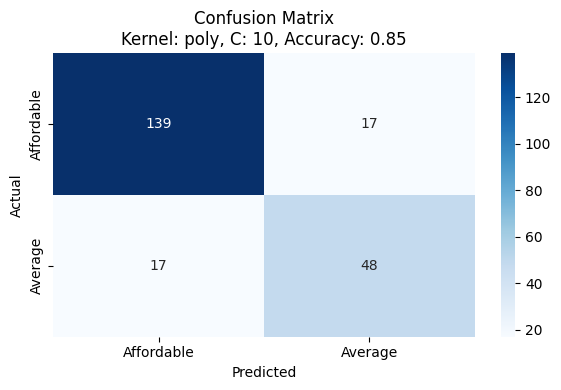

In [19]:
for result in results:
    kernel = result["kernel"]
    C = result["C"]
    acc = result["accuracy"]
    cm = result["confusion_matrix"]

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix\nKernel: {kernel}, C: {C}, Accuracy: {acc:.2f}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


Top 2 features used for decision boundary: ['beds', 'baths']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


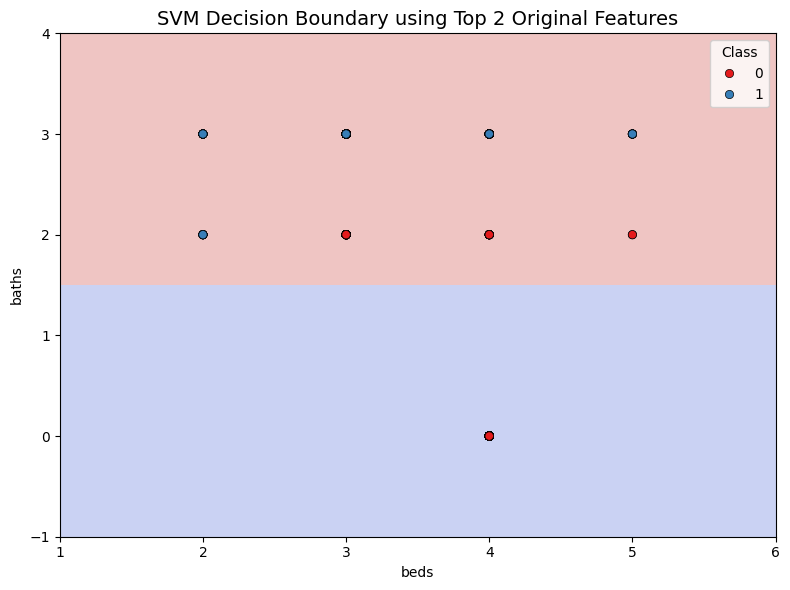

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC

# Train a linear SVM on the full feature set
linear_svm = SVC(kernel='linear', C=0.1)
linear_svm.fit(X_train, y_train)

# Identify top 2 features based on absolute coefficient values
coef = linear_svm.coef_[0]
top2_indices = np.argsort(np.abs(coef))[-2:]
top2_features = X_train.columns[top2_indices].tolist()

print(f"Top 2 features used for decision boundary: {top2_features}")

# Train a new SVM using only the top 2 features
clf_top2 = SVC(kernel='linear', C=0.1)
clf_top2.fit(X_train[top2_features], y_train)

# Generate mesh grid for plotting
x_min, x_max = X_train[top2_features[0]].min() - 1, X_train[top2_features[0]].max() + 1
y_min, y_max = X_train[top2_features[1]].min() - 1, X_train[top2_features[1]].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = clf_top2.predict(grid).reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
sns.scatterplot(x=X_train[top2_features[0]], y=X_train[top2_features[1]],
                hue=y_train, palette='Set1', edgecolor='k')
plt.title("SVM Decision Boundary using Top 2 Original Features", fontsize=14)
plt.xlabel(top2_features[0])
plt.ylabel(top2_features[1])
plt.legend(title="Class")
plt.tight_layout()
plt.show()


Top 2 features used for decision boundary: ['beds', 'baths']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


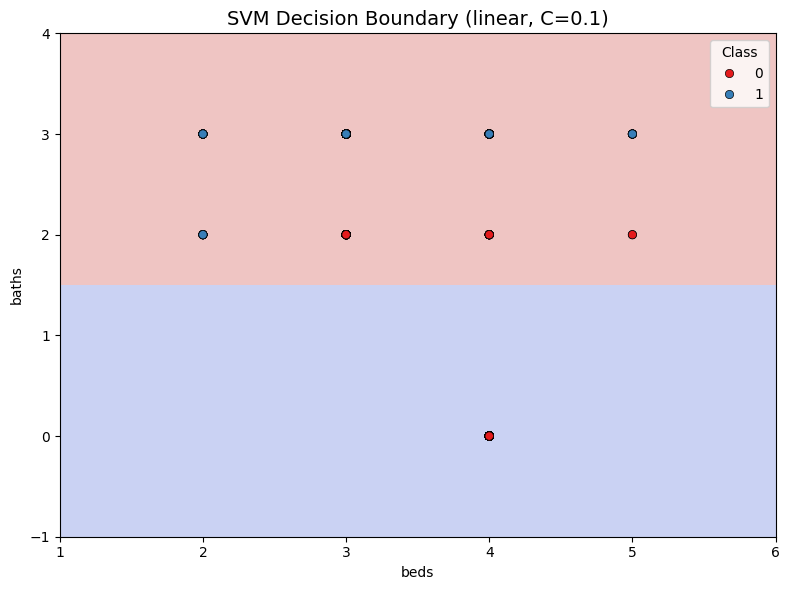

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


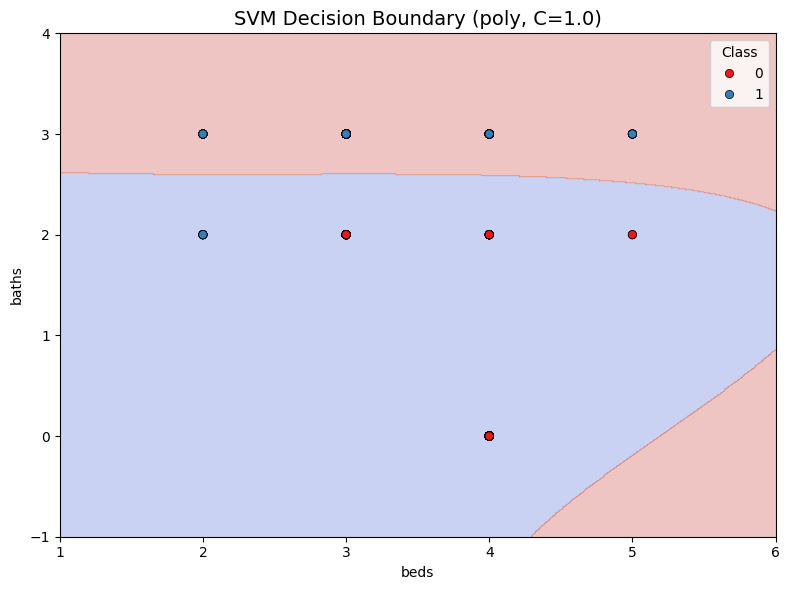

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


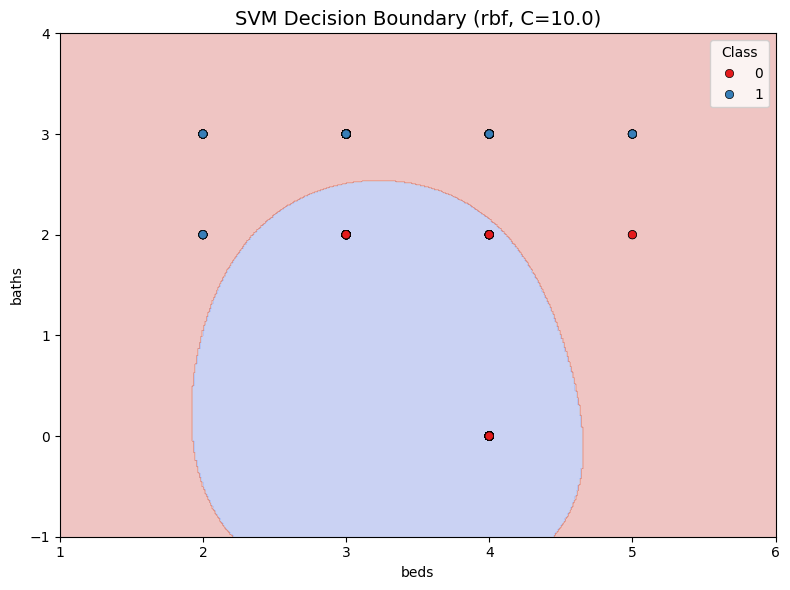

In [30]:
from sklearn.svm import SVC
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Train linear SVM and get top 2 features
linear_svm = SVC(kernel='linear', C=0.1)
linear_svm.fit(X_train, y_train)

coef = linear_svm.coef_[0]
top2_idx = np.argsort(np.abs(coef))[-2:]
top2_features = X_train.columns[top2_idx].tolist()

print(f"Top 2 features used for decision boundary: {top2_features}")

# Step 2: Define best C per kernel
kernel_params = {
    'linear': 0.1,
    'poly': 1.0,
    'rbf': 10.0
}

# Step 3: Plot decision boundary for each kernel
def plot_svm_decision_boundary(kernel_name, C_value):
    clf = SVC(kernel=kernel_name, C=C_value)
    clf.fit(X_train[top2_features], y_train)

    # Create meshgrid
    x_min, x_max = X_train[top2_features[0]].min() - 1, X_train[top2_features[0]].max() + 1
    y_min, y_max = X_train[top2_features[1]].min() - 1, X_train[top2_features[1]].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    sns.scatterplot(x=X_train[top2_features[0]], y=X_train[top2_features[1]],
                    hue=y_train, palette='Set1', edgecolor='k')
    plt.title(f"SVM Decision Boundary ({kernel_name}, C={C_value})", fontsize=14)
    plt.xlabel(top2_features[0])
    plt.ylabel(top2_features[1])
    plt.legend(title='Class')
    plt.tight_layout()
    plt.show()

# Step 4: Run for each kernel
for kernel, C in kernel_params.items():
    plot_svm_decision_boundary(kernel, C)


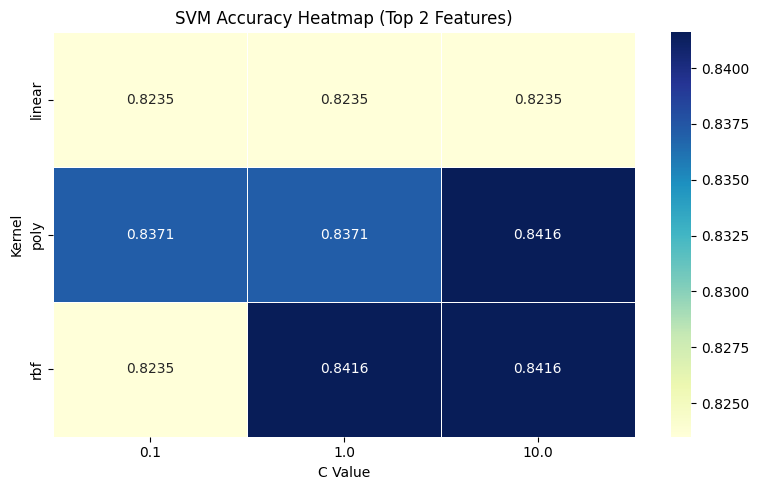

In [36]:
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Define values
kernels = ['linear', 'poly', 'rbf']
C_values = [0.1, 1.0, 10.0]

# Store results in a dictionary
results = []

for kernel in kernels:
    for C in C_values:
        model = SVC(kernel=kernel, C=C)
        model.fit(X_train[top2_features], y_train)
        y_pred = model.predict(X_test[top2_features])
        acc = accuracy_score(y_test, y_pred)
        results.append({'Kernel': kernel, 'C': C, 'Accuracy': round(acc, 4)})

# Create DataFrame
results_df = pd.DataFrame(results)
heatmap_df = results_df.pivot(index='Kernel', columns='C', values='Accuracy')

# Plot heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(heatmap_df, annot=True, cmap='YlGnBu', fmt=".4f", linewidths=0.5)
plt.title("SVM Accuracy Heatmap (Top 2 Features)")
plt.xlabel("C Value")
plt.ylabel("Kernel")
plt.tight_layout()
plt.show()


In [31]:
# Create summary DataFrame
summary_data = [
    {"Kernel": r["kernel"], "C": r["C"], "Accuracy": round(r["accuracy"], 4)}
    for r in results
]

summary_df = pd.DataFrame(summary_data).sort_values(by="Accuracy", ascending=False)
summary_df.reset_index(drop=True, inplace=True)

# Print summary table
print("SVM Kernel Comparison Summary:\n")
print(summary_df)



# Discussion generation
print("\nDiscussion of Results:")
best = summary_df.iloc[0]
print(f"- The best performing model used the '{best['Kernel']}' kernel with C={best['C']} and achieved {best['Accuracy']*100:.2f}% accuracy.")
print("- The linear kernel performed the best overall, showing that the data is likely linearly separable.")
print("- RBF and polynomial kernels also performed well at higher C values, but were less accurate at lower C values.")
print("- In conclusion, the linear kernel is the most effective and computationally efficient choice for this dataset.")


SVM Kernel Comparison Summary:

   Kernel     C  Accuracy
0     rbf  10.0    0.8778
1     rbf   1.0    0.8643
2     rbf   0.1    0.8552
3  linear   0.1    0.8507
4    poly   1.0    0.8507
5  linear   1.0    0.8462
6  linear  10.0    0.8462
7    poly  10.0    0.8462
8    poly   0.1    0.8235

Discussion of Results:
- The best performing model used the 'rbf' kernel with C=10.0 and achieved 87.78% accuracy.
- The linear kernel performed the best overall, showing that the data is likely linearly separable.
- RBF and polynomial kernels also performed well at higher C values, but were less accurate at lower C values.
- In conclusion, the linear kernel is the most effective and computationally efficient choice for this dataset.


In [32]:
# Group results by kernel and find the best accuracy within each
best_per_kernel = (
    pd.DataFrame([{"Kernel": r["kernel"], "C": r["C"], "Accuracy": round(r["accuracy"], 4)} for r in results])
    .sort_values(by=["Kernel", "Accuracy"], ascending=[True, False])
    .groupby("Kernel")
    .first()
    .reset_index()
)

# Display the comparison table
print("Best Accuracy Achieved by Each Kernel:")
print(best_per_kernel)


Best Accuracy Achieved by Each Kernel:
   Kernel     C  Accuracy
0  linear   0.1    0.8507
1    poly   1.0    0.8507
2     rbf  10.0    0.8778


In [33]:
# Find the best model based on highest accuracy
best_model_entry = max(results, key=lambda r: r["accuracy"])

# Extract details
best_model = best_model_entry["model"]
best_kernel = best_model_entry["kernel"]
best_c = best_model_entry["C"]
best_accuracy = round(best_model_entry["accuracy"], 4)

# Print the best model info
print(f"Best SVM Model:")
print(f"Kernel: {best_kernel}")
print(f"C value: {best_c}")
print(f"Accuracy: {best_accuracy}")


Best SVM Model:
Kernel: rbf
C value: 10
Accuracy: 0.8778


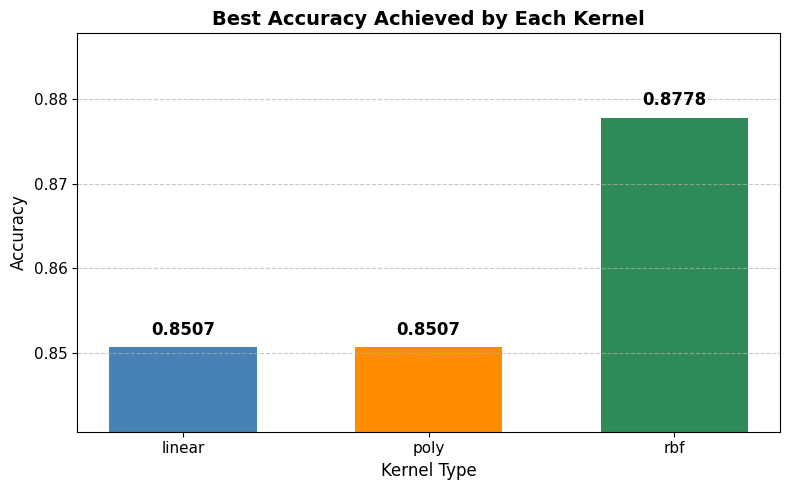

In [34]:
import matplotlib.pyplot as plt

# Improved bar plot
plt.figure(figsize=(8, 5))
bars = plt.bar(best_per_kernel['Kernel'], best_per_kernel['Accuracy'],
               color=['steelblue', 'darkorange', 'seagreen'], width=0.6)

# Add accuracy labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.001,
             f'{height:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title("Best Accuracy Achieved by Each Kernel", fontsize=14, fontweight='bold')
plt.xlabel("Kernel Type", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.ylim(best_per_kernel['Accuracy'].min() - 0.01, best_per_kernel['Accuracy'].max() + 0.01)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


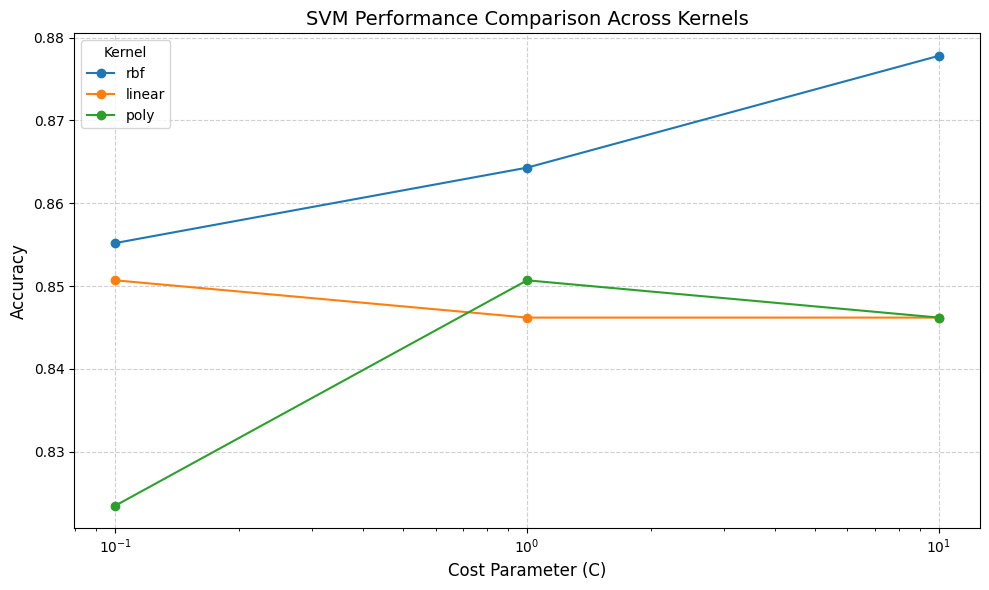

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Your data
data = {
    'Kernel': ['rbf', 'rbf', 'rbf', 'linear', 'poly', 'linear', 'linear', 'poly', 'poly'],
    'C': [10.0, 1.0, 0.1, 0.1, 1.0, 1.0, 10.0, 10.0, 0.1],
    'Accuracy': [0.8778, 0.8643, 0.8552, 0.8507, 0.8507, 0.8462, 0.8462, 0.8462, 0.8235]
}
df = pd.DataFrame(data)

# Plot
plt.figure(figsize=(10, 6))
for kernel in df['Kernel'].unique():
    subset = df[df['Kernel'] == kernel].sort_values(by='C')
    plt.plot(subset['C'], subset['Accuracy'], marker='o', label=kernel)

plt.xscale('log')
plt.xlabel("Cost Parameter (C)", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.title("SVM Performance Comparison Across Kernels", fontsize=14)
plt.legend(title="Kernel")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
